In [1]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('D:\\Salzburg\\TexSense\\Messungen\\IMU\\treadmill_finki\\finki__18.txt', sep='\t', header=1) 
lf = df[df.columns[df.columns.str.contains(pat = 'L_Foot')]]
rf = df[df.columns[df.columns.str.contains(pat = 'R_Foot')]]

In [3]:
def butter_2nd(sig, fs, f_cut):
    # design filter
    b, a = butter(2, f_cut / fs, btype='low')
    # apply filter
    sig_filt = filtfilt(b, a, sig, axis=0)
    return sig_filt

In [147]:

def get_midswing(gyr_y_series, fs):
    """
    finds peaks in Angular Velocity around Y Axis of Foot IMU with distance of at least 0.5 s for the same side
    :param gyr_y_series: array or pd.Series with gyr_y signal
    :param fs: integer with sampling rate
    :return int array with mid_swing indices:
    """
    gyr_y_filt = butter_2nd(gyr_y_series, 2000, 90)
    mid_swing, _ = find_peaks(gyr_y_filt, distance = fs * 60 / 100)
    return mid_swing

def get_midstance(foot_imu_side, mid_swing_side):
    """
    finds midstance (global minimum in the Angular Velocity Norm of Foot IMU in the interval between Midswing and 40 % of the following Midswing
    :param foot_imu_side: pd.DataFrame with IMU Data of one Side
    :param mid_swing_side: int array with mid_swing indices
    :return mid_stance_side: int array with mid_stance indices
    """
    # foot gyro signals are stored at index [3:6] in the IMU df
    ang_norm = np.linalg.norm(foot_imu_side.iloc[:,3:6], axis = 1)

    # initialize empty list
    mid_stance_side = []

    # loop over all mid_swing events - 1
    # get minimum in ang_norm in the interval of:
    # mid_swing[i] to mid_swing[i] + 40 % of the distance to mid_swing[i+1]
    # add index of current mid_swing to the found mid_stance index and append to list
    for i in range(len(mid_swing_side) - 1):
        mid_stance_side.append(np.argmin(
            ang_norm[mid_swing_side[i]:mid_swing_side[i] + (2 * (mid_swing_side[i + 1] - mid_swing_side[i])) // 5]) +
                               mid_swing_side[i])

    return np.array(mid_stance_side)

def get_detection_windows(foot_imu_df, sampling_rate):
    """
    calculates the search windows for  IC and TO search
    :param foot_imu_df: DataFrame with Foot IMU for one Side
    :param sampling_rate: Sampling Rate - integer
    :return window_dict: dict with Lists of interval boundries for IC and TO search
    """

    # get midswing indices
    midswing = get_midswing(foot_imu_df.iloc[:,4], sampling_rate)

    # filter all Data at 30 Hz
    foot_df_filt = pd.DataFrame(butter_2nd(foot_imu_df, sampling_rate, 30), columns=foot_imu_df.columns)

    # get interval boundries based on Angular Velocity Signal
    ang_norm = np.linalg.norm(foot_df_filt.iloc[:,3:6], axis = 1)

    # init empty lists
    TO_end = []
    IC_start = []
    mid = []

    # for each step (between 2 midswing events):
    # find 3 peaks (1st = midstance, 2nd = TO upper boundry, 3rd = IC lower boundry (of the next step))
    for i in range(len(midswing) - 1):
        peaks, _ = find_peaks(-ang_norm[midswing[i]:midswing[i + 1]], prominence=150)
        try:
            len(peaks)==3
        except:
            print('Error in window detection:'
                  'did not find 3 peaks in ang_norm signal between'
                  'midswing['+str(i)+'] and midswing['+str(i+1)+']')
        mid.append(peaks[0] + midswing[i])
        TO_end.append(peaks[1] + midswing[i])
        IC_start.append(peaks[2] + midswing[i])

    # clip first element of mid and TO_end & last element of IC_start to allign order
    mid = mid[1:]
    TO_end = TO_end[1:]
    IC_start = IC_start[:-1]

    window_dict = {'lower_IC': IC_start,
                   'upper_IC': mid,
                   'lower_TO': mid,
                   'upper_TO': TO_end}
    return window_dict

# IC_detection methods
def k1(slice_df):
    """
    global minimum of angular velocity around y
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC as int
    """
    return int(slice_df.iloc[:,4].idxmin())

def k3(slice_df):
    """
    first minimum of angular velocity around y < 100°/s
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    # find first peak lower than 100
    peaks, _ = find_peaks(-slice_df.iloc[:,4], height = -100)
    try:
        IC = int(peaks[0] + slice_df.index[0])
    except:
        print('could not find IC in k3')
        IC = None
    return IC

def k7(slice_df):
    """
    global maximum of angular velocity norm
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return int(np.argmax(np.linalg.norm(slice_df.iloc[:,3:6], axis = 1)) + slice_df.index[0])

def k8(slice_df):
    """
    global maximum of vertical acceleration
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return int(slice_df.iloc[:,2].idxmax())

def k9(slice_df):
    """
    global maximum of acceleration norm
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return int(np.argmax(np.linalg.norm(slice_df.iloc[:,:3], axis = 1)) + slice_df.index[0])

def t1(slice_df):
    """
    global minimum of angular velocity around y
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return k1(slice_df)

def t4(slice_df):
    """
    global maximum of angular velocity norm
    :param slice_df: DataFrame slice of current interval for IC detection
    :return IC index as int
    """
    return k7(slice_df)

def t8(slice_df):
    """
        global maximum of angular velocity norm
        :param slice_df: DataFrame slice of current interval for IC detection
        :return IC index as int
        """
    return k9(slice_df)

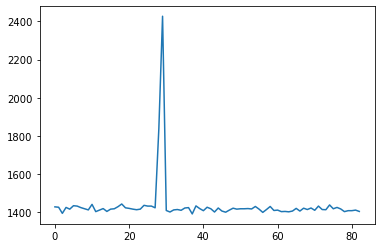

In [111]:
# view regularity:
plt.plot(np.diff(mid_swing, n=1))

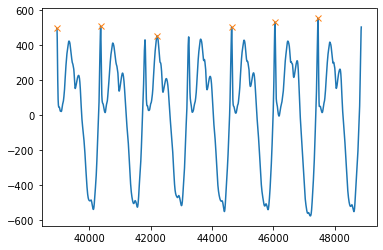

In [112]:
# view window (5 instances)
s = 27
e = 33
ly_filt=pd.Series(ly_filt)
window = ly_filt[mid_swing[s]:mid_swing[e]]
ms_window = get_midswing(window, 2000)
plt.plot(window)
plt.plot(mid_swing[s:e], window[mid_swing[s:e]], 'x')
#plt.plot(window.values)
#plt.plot(ms_window, window.values[ms_window], 'x')

In [116]:
rf

,R_Foot_ImuAcc :X(g):,R_Foot_ImuAcc :Y(g):,R_Foot_ImuAcc :Z(g):,R_Foot_Gyro :X(D/s):,R_Foot_Gyro :Y(D/s):,R_Foot_Gyro :Z(D/s):,R_Foot_Mag :X(uT):,R_Foot_Mag :Y(uT):,R_Foot_Mag :Z(uT):
0,-0.4688,0.5089,1.8550,-53.6951,-67.8644,55.8576,77.8500,-15.7500,-31.0500
1,-0.4566,0.5354,1.8419,-52.2564,-69.6171,57.0347,77.8500,-15.7500,-31.0500
2,-0.4443,0.5619,1.8287,-50.8177,-71.3697,58.2119,77.8500,-15.7500,-31.0500
3,-0.4321,0.5884,1.8155,-49.3789,-73.1223,59.3890,77.8500,-15.7500,-31.0500
4,-0.4222,0.6081,1.8052,-48.3936,-75.5289,60.2435,77.8929,-15.7071,-31.2536
...,...,...,...,...,...,...,...,...,...
121003,-5.2443,-2.9923,0.9594,-160.8500,530.2460,-231.3303,19.0286,-26.2286,-21.5786
121004,-5.6725,-2.9723,1.4187,-149.9767,540.5526,-236.8236,18.8893,-26.0143,-21.5893
121005,-6.1008,-2.9522,1.8780,-139.1034,550.8591,-242.3170,18.7500,-25.8000,-21.6000
121006,-5.9687,-2.6841,2.2099,-116.3802,556.5181,-245.8571,18.5571,-25.9714,-21.2464


In [148]:
windows_right = get_detection_windows(rf, 2000)
windows_left = get_detection_windows(lf, 2000)

In [149]:
events_left = pd.DataFrame(data=None)
for i in range(len(windows_left['lower_IC'])):

    # IC Detection: slice current detection window
    ic_window = lf.loc[windows_left['lower_IC'][i]:windows_left['upper_IC'][i]]

    # k1 global min of angular velocity around Y
    events_left.loc[i, 'IC_1']=k1(ic_window)
    # k3 first min of angular velocity around Y < 100°/s
    events_left.loc[i, 'IC_3'] = k3(ic_window)
    # k7 global max of angular velocity norm
    events_left.loc[i, 'IC_7'] = k7(ic_window)
    # k8 global max of vertical acceleration (Z)
    events_left.loc[i, 'IC_8'] = k8(ic_window)
    # k9 global max of acceleration norm
    events_left.loc[i, 'IC_9'] = k9(ic_window)

    # TO Detection8 window
    to_window = lf.loc[windows_left['lower_TO'][i]:windows_left['upper_TO'][i]]

    # t1 global min of angular velocity around Y
    events_left.loc[i, 'TO_1'] = t1(to_window)
    # t4 global max of angular velocity norm
    events_left.loc[i, 'TO_4'] = t4(to_window)
    # t8 global max of acceleration norm
    events_left.loc[i, 'TO_8'] = t8(to_window)

# right side:
events_right = pd.DataFrame(data=None)
for i in range(len(windows_right['lower_IC'])):

    # IC Detection: slice current detection window
    ic_window = rf.loc[windows_right['lower_IC'][i]:windows_right['upper_IC'][i]]

    # k1 global min of angular velocity around Y
    events_right.loc[i, 'IC_1']=k1(ic_window)
    # k3 first min of angular velocity around Y < 100°/s
    events_right.loc[i, 'IC_3'] = k3(ic_window)
    # k7 global max of angular velocity norm
    events_right.loc[i, 'IC_7'] = k7(ic_window)
    # k8 global max of vertical acceleration (Z)
    events_right.loc[i, 'IC_8'] = k8(ic_window)
    # k9 global max of acceleration norm
    events_right.loc[i, 'IC_9'] = k9(ic_window)

    # TO Detection8 window
    to_window = rf.loc[windows_right['lower_TO'][i]:windows_right['upper_TO'][i]]

    # t1 global min of angular velocity around Y
    events_right.loc[i, 'TO_1'] = t1(to_window)
    # t4 global max of angular velocity norm
    events_right.loc[i, 'TO_4'] = t4(to_window)
    # t8 global max of acceleration norm
    events_right.loc[i, 'TO_8'] = t8(to_window)

could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3
could not find IC in k3


In [161]:
events_right

,IC_1,IC_3,IC_7,IC_8,IC_9,TO_1,TO_4,TO_8
0,1926.0,2047.0,1998.0,2005.0,2012.0,2861.0,2404.0,2782.0
1,3356.0,3489.0,3426.0,3440.0,3433.0,4242.0,3797.0,4189.0
2,4754.0,4882.0,4819.0,4826.0,4826.0,5664.0,5197.0,5589.0
3,6173.0,6289.0,6240.0,6247.0,6254.0,7080.0,6639.0,7017.0
4,7586.0,7696.0,7661.0,7675.0,7668.0,8502.0,8053.0,8438.0
...,...,...,...,...,...,...,...,...
77,112479.0,112598.0,112556.0,112563.0,112563.0,113371.0,112948.0,113305.0
78,113874.0,114012.0,113956.0,114005.0,113963.0,114782.0,114341.0,114712.0
79,115292.0,115433.0,115363.0,115363.0,115370.0,116185.0,115762.0,116126.0
80,116697.0,116833.0,116770.0,116777.0,116735.0,117600.0,117176.0,117540.0


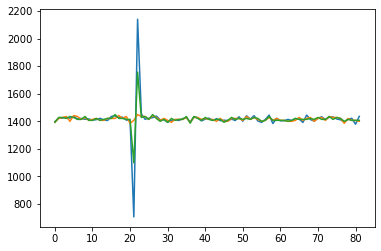

In [186]:
plt.plot(np.diff(TO, n=1, axis = 0))

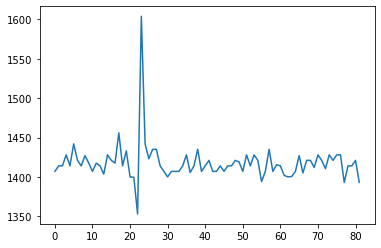

In [163]:
plt.plot(np.nanmedian(np.diff(events_left.iloc[:,:5], n=1, axis = 0), axis = 1))

In [167]:
IC = events_left.iloc[:,:5]
IC

,IC_1,IC_3,IC_7,IC_8,IC_9
0,2651.0,2782.0,2719.0,2733.0,2684.0
1,4053.0,4189.0,4126.0,4140.0,4098.0
2,5473.0,5603.0,5540.0,5554.0,5547.0
3,6884.0,6989.0,6954.0,6968.0,6968.0
4,8316.0,8452.0,8382.0,8396.0,8396.0
...,...,...,...,...,...
78,113180.0,113312.0,113242.0,113263.0,113214.0
79,114592.0,114726.0,114656.0,114670.0,114628.0
80,116006.0,NaN,116070.0,116084.0,116035.0
81,117423.0,117561.0,117491.0,117505.0,117498.0


In [178]:
from scipy.stats import zscore
zf = IC.apply(zscore, axis = 1, nan_policy='omit')
zf

,IC_1,IC_3,IC_7,IC_8,IC_9
0,-1.412839,1.534325,0.116987,0.431951,-0.670423
1,-1.512734,1.503862,0.106468,0.417000,-0.514596
2,-1.693051,1.433322,-0.081767,0.254920,0.086576
3,-1.901569,1.008996,0.038808,0.426883,0.426883
4,-1.665958,1.463466,-0.147267,0.174880,0.174880
...,...,...,...,...,...
78,-1.393009,1.563216,-0.004479,0.465829,-0.631557
79,-1.397881,1.603979,0.035843,0.349470,-0.591411
80,-1.403574,NaN,0.697683,1.157333,-0.451442
81,-1.651434,1.487655,-0.104636,0.213822,0.054593


<AxesSubplot:>

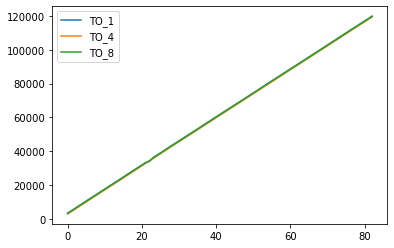

In [185]:
TO = events_left.iloc[:,5:]
TO.plot()

In [184]:
np.mean(abs(IC['IC_7']-IC['IC_8']))

20.240963855421686